# Modelado XGBoost
**Objetivo:** Identificar qué clientes tienen mayor probabilidad de aceptar un crédito, para optimizar la campaña de llamadas del banco.

Construimos un modelo XGBoost que predice la probabilidad de conversión de cada cliente y usamos un threshold optimizado para equilibrar precisión y recall.

**¿Por qué XGBoost?**
- Maneja bien datos tabulares
- Captura relaciones no lineales
- Robusto ante desbalance de clases

---
**Estructura del notebook:**
1. Instalación e importaciones
2. Carga de datos
3. Modelo baseline XGBoost
4. Métricas (F1 como principal)
5. Ajuste de threshold
6. Gráfico de Validation Curve
7. Cross-Validation
8. Análisis Lift / Segmentación
9. Visualizaciones
10. Guardar modelo baseline
11. **Optuna** — Búsqueda de hiperparámetros
12. Modelo final optimizado
13. Comparación baseline vs Optuna
14. Guardar mejor modelo

---
## 1. Instalación e Importaciones

Instalamos las librerías necesarias e importamos todo lo que usaremos a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

import optuna
import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    validation_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 2. Carga de Datos

Cargamos los conjuntos de entrenamiento y prueba preprocesados.

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Balance clases — Train: {np.bincount(y_train)} | Test: {np.bincount(y_test)}")

Train: (63874, 51) | Test: (9043, 51)
Balance clases — Train: [31937 31937] | Test: [7985 1058]


---
## 3. Modelo Baseline XGBoost

Entrenamos un primer modelo con parámetros razonables.

**¿Cómo funciona XGBoost?**  
Construye múltiples árboles secuenciales, donde cada nuevo árbol corrige errores del anterior.
La combinación final produce una probabilidad entre 0 y 1.

In [3]:
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_baseline.fit(X_train, y_train)

y_pred_base   = xgb_baseline.predict(X_test)
y_proba_base  = xgb_baseline.predict_proba(X_test)[:, 1]

print("=== Modelo Baseline (threshold=0.5) ===")
print(classification_report(y_test, y_pred_base))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_base):.4f}")

=== Modelo Baseline (threshold=0.5) ===
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7985
           1       0.57      0.30      0.39      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.63      0.67      9043
weighted avg       0.87      0.89      0.88      9043

ROC-AUC : 0.7917
F1-Score: 0.3908


---
## 4. Ajuste de Threshold — Optimización de F1

**Métrica principal: F1-Score** (equilibrio entre Precision y Recall).

En lugar de usar el threshold por defecto (0.5), buscamos el valor que **maximiza el F1** sobre el conjunto de test.

Esto es especialmente útil cuando las clases están desbalanceadas.

Mejor threshold : 0.2929
Mejor F1-Score  : 0.4793


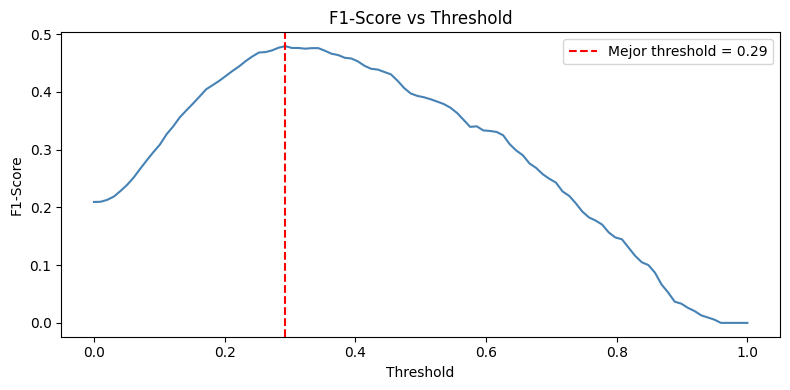

In [4]:
thresholds = np.linspace(0, 1, 100)
f1_scores  = []

for t in thresholds:
    preds = (y_proba_base >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f"Mejor threshold : {best_threshold:.4f}")
print(f"Mejor F1-Score  : {best_f1:.4f}")

# Visualización
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='steelblue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Mejor threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('F1-Score vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Evaluar baseline con threshold optimizado
threshold_baseline = best_threshold
y_pred_base_opt    = (y_proba_base >= threshold_baseline).astype(int)

print(f"=== Baseline con threshold={threshold_baseline:.2f} ===")
print(classification_report(y_test, y_pred_base_opt))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_base_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base_opt):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred_base_opt):.4f}")

=== Baseline con threshold=0.29 ===
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      7985
           1       0.45      0.51      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.71      0.70      9043
weighted avg       0.88      0.87      0.87      9043

ROC-AUC : 0.7917
F1-Score: 0.4793
Precision: 0.4495
Recall  : 0.5132


---
## 5. Validation Curve — max_depth

La **Validation Curve** nos muestra cómo cambia el rendimiento del modelo en train y validación
al variar un hiperparámetro clave.

Analizamos `max_depth`: valores muy altos pueden provocar **overfitting**.

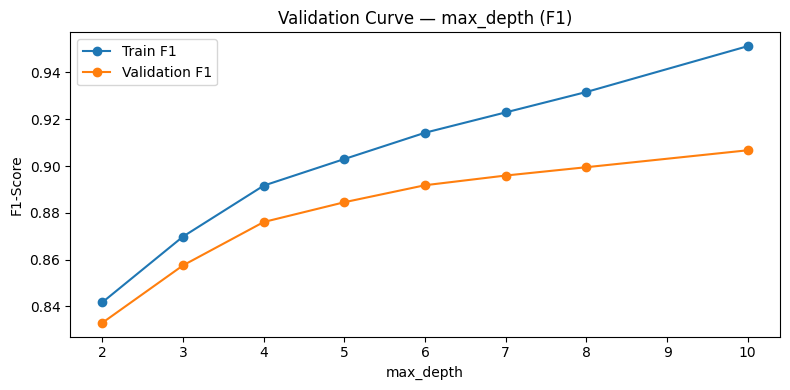

In [6]:
param_range = [2, 3, 4, 5, 6, 7, 8, 10]

train_scores, val_scores = validation_curve(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=3,
    scoring="f1",       # F1 como métrica principal
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(param_range, train_mean, marker='o', label='Train F1')
plt.plot(param_range, val_mean,   marker='o', label='Validation F1')
plt.xlabel('max_depth')
plt.ylabel('F1-Score')
plt.title('Validation Curve — max_depth (F1)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 6. Cross-Validation (StratifiedKFold)

Usamos **Stratified K-Fold** para garantizar que la proporción de clases sea similar en cada fold.

Esto nos da una estimación más robusta del rendimiento real del modelo.

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1 = cross_val_score(
    xgb_baseline, X_train, y_train,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

cv_auc = cross_val_score(
    xgb_baseline, X_train, y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print("=== Cross-Validation (5-Fold) ===")
print(f"F1  por fold : {cv_f1.round(4)}")
print(f"F1  promedio : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print()
print(f"AUC por fold : {cv_auc.round(4)}")
print(f"AUC promedio : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

=== Cross-Validation (5-Fold) ===
F1  por fold : [0.9247 0.9245 0.9248 0.9233 0.925 ]
F1  promedio : 0.9245 ± 0.0006

AUC por fold : [0.9726 0.97   0.9722 0.9709 0.9713]
AUC promedio : 0.9714 ± 0.0009


---
## 7. Análisis Lift / Segmentación de Clientes

Convertimos las probabilidades en segmentos de negocio para medir el impacto real.

**Lift Top 20%:** ¿Cuánto mejor es nuestro modelo vs llamar a todos?

**Segmentos:**
- 🔴 **Alta** → Top 20% — mayor probabilidad de conversión
- 🟡 **Media** → siguiente 30%
- 🟢 **Baja** → 50% restante

In [8]:
df_eval = pd.DataFrame({"proba": y_proba_base, "real": y_test})

# Lift Top 20%
top_percent = 20
cutoff      = np.percentile(df_eval["proba"], 100 - top_percent)
top_clients = df_eval[df_eval["proba"] >= cutoff]

conversion_general = df_eval["real"].mean()
conversion_top     = top_clients["real"].mean()
lift               = conversion_top / conversion_general

print(f"Conversión general    : {conversion_general:.2%}")
print(f"Conversión Top {top_percent}%   : {conversion_top:.2%}")
print(f"Lift Top {top_percent}%         : {lift:.2f}x")

# Segmentación
p80 = np.percentile(y_proba_base, 80)
p50 = np.percentile(y_proba_base, 50)

def segmentar(prob):
    if prob >= p80: return "Alta"
    elif prob >= p50: return "Media"
    else: return "Baja"

df_eval["segmento"] = df_eval["proba"].apply(segmentar)

print("\n=== Distribución por segmento ===")
print(df_eval["segmento"].value_counts(normalize=True).map("{:.2%}".format))

Conversión general    : 11.70%
Conversión Top 20%   : 35.27%
Lift Top 20%         : 3.01x

=== Distribución por segmento ===
segmento
Baja     49.99%
Media    30.00%
Alta     20.00%
Name: proportion, dtype: str


---
## 8. Visualizaciones

Gráficos para comunicar el rendimiento del modelo y su impacto en negocio.

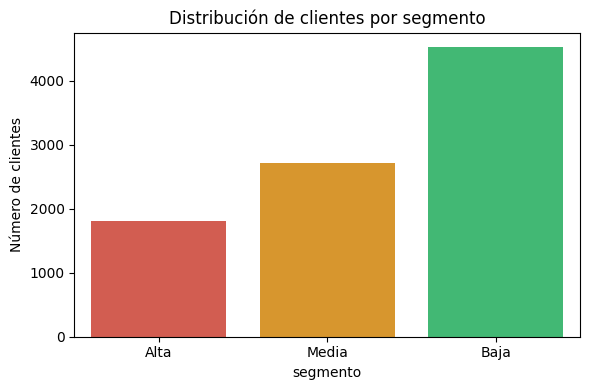

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eval, x="segmento", order=["Alta", "Media", "Baja"],
              palette=["#e74c3c", "#f39c12", "#2ecc71"])
plt.title("Distribución de clientes por segmento")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

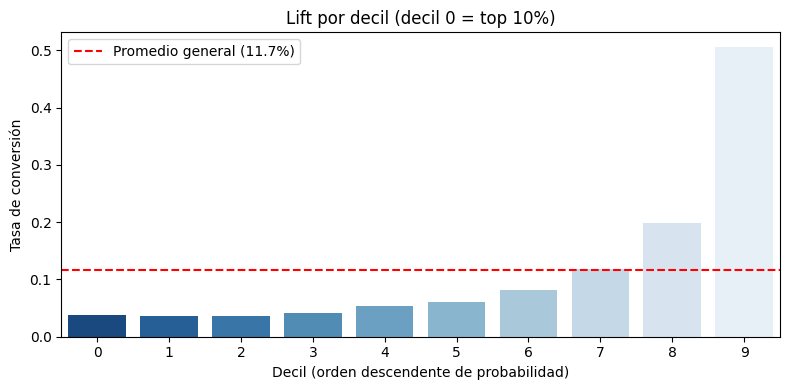


📌 Mensaje clave:
Si llamamos a TODOS los clientes → conversión promedio 11.7%
Si enfocamos el TOP 20% del modelo → conversión 35.3%
→ Lift de 3.0x  (triplicamos efectividad sin costos adicionales)



In [10]:
df_eval["decile"] = pd.qcut(df_eval["proba"], 10, labels=False)
lift_table = df_eval.groupby("decile")["real"].mean().sort_index(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=lift_table.index, y=lift_table.values, palette="Blues_r")
plt.axhline(conversion_general, color='red', linestyle='--', label=f'Promedio general ({conversion_general:.1%})')
plt.title("Lift por decil (decil 0 = top 10%)")
plt.ylabel("Tasa de conversión")
plt.xlabel("Decil (orden descendente de probabilidad)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"""
📌 Mensaje clave:
Si llamamos a TODOS los clientes → conversión promedio {conversion_general:.1%}
Si enfocamos el TOP 20% del modelo → conversión {conversion_top:.1%}
→ Lift de {lift:.1f}x  (triplicamos efectividad sin costos adicionales)
""")

---
## 9. Guardar Modelo Baseline

Guardamos el modelo baseline para poder compararlo después con el modelo optimizado por Optuna.

In [11]:
baseline_artifact = {
    "model"     : xgb_baseline,
    "threshold" : threshold_baseline,
    "features"  : X_train.columns.tolist(),
    "metrics": {
        "f1"      : f1_score(y_test, y_pred_base_opt),
        "roc_auc" : roc_auc_score(y_test, y_proba_base),
        "precision": precision_score(y_test, y_pred_base_opt),
        "recall"  : recall_score(y_test, y_pred_base_opt),
    }
}

joblib.dump(baseline_artifact, "../models/xgb_baseline.pkl")
print("✅ Modelo baseline guardado en ../models/xgb_baseline.pkl")

✅ Modelo baseline guardado en ../models/xgb_baseline.pkl


---
## 10. Optuna — Búsqueda de Hiperparámetros

**Optuna** usa **TPE (Tree-structured Parzen Estimator)** para buscar hiperparámetros de forma inteligente,
a diferencia de Grid Search que prueba exhaustivamente todas las combinaciones.

**Optimizaciones de velocidad aplicadas:**
- `cv=3` en lugar de 5
- `n_jobs=1` en el modelo (evita conflicto con paralelismo de Optuna)
- `early_stopping_rounds` en cada fold
- `MedianPruner` — cancela trials malos antes de terminar
- `n_jobs=4` en `study.optimize` — trials en paralelo
- Callback de early stopping: para si no mejora en 20 trials seguidos

In [12]:
from sklearn.metrics import roc_auc_score as auc_score

def objective(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"         : trial.suggest_int("max_depth", 3, 10),
        "learning_rate"     : trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
        "subsample"         : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight"  : trial.suggest_int("min_child_weight", 1, 10),
        "gamma"             : trial.suggest_float("gamma", 0, 5),
        "reg_alpha"         : trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda"        : trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "objective"         : "binary:logistic",
        "eval_metric"       : "logloss",
        "early_stopping_rounds": 30,
        "n_jobs"            : 1,
        "random_state"      : 42,
    }

    cv  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1s = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        y_proba_fold = model.predict_proba(X_val)[:, 1]

        # Buscar threshold óptimo por F1 en validación
        ths = np.linspace(0.1, 0.9, 50)
        best_f = max(f1_score(y_val, (y_proba_fold >= t).astype(int), zero_division=0) for t in ths)
        f1s.append(best_f)

        # Pruning: cancela trials malos desde el primer fold
        trial.report(np.mean(f1s), step=len(f1s))
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(f1s)


optuna.logging.set_verbosity(optuna.logging.WARNING)

pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)

study = optuna.create_study(
    direction="maximize",
    pruner=pruner,
    study_name="xgboost_f1_optuna"
)

study.optimize(
    objective,
    n_trials=100,
    n_jobs=4,
    show_progress_bar=True,
    callbacks=[
        lambda study, trial: study.stop()
        if study.best_trial.number + 20 < trial.number else None
    ]
)

print(f"\n✅ Mejor F1 (CV): {study.best_value:.4f}")
print(f"📌 Mejores parámetros:\n{study.best_params}")

Best trial: 30. Best value: 0.933394:  55%|█████▌    | 55/100 [16:08<13:12, 17.62s/it]


✅ Mejor F1 (CV): 0.9334
📌 Mejores parámetros:
{'n_estimators': 326, 'max_depth': 10, 'learning_rate': 0.06980626318256161, 'subsample': 0.6355661717853055, 'colsample_bytree': 0.8543977876806425, 'min_child_weight': 4, 'gamma': 0.48542993085630326, 'reg_alpha': 8.16792375325177e-05, 'reg_lambda': 5.229824543588736e-06}


### Visualización de Optuna

Analizamos la importancia de los hiperparámetros y la historia de optimización.

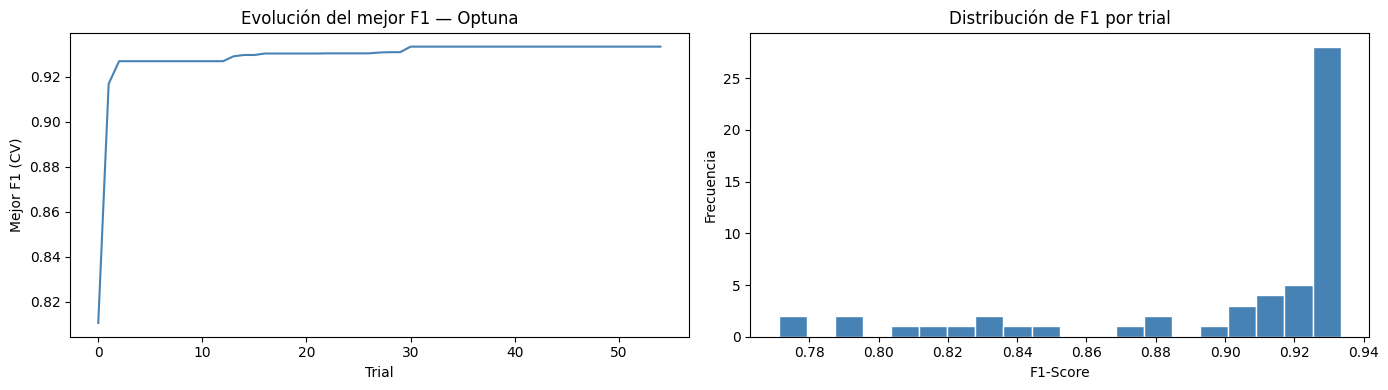

Total de trials completados : 55
Trials podados (pruned)     : 19


In [17]:
import optuna.visualization.matplotlib as optuna_plt

# Historia de optimización
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: evolución del mejor F1
best_vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(best_vals)
axes[0].plot(running_best, color='steelblue')
axes[0].set_title('Evolución del mejor F1 — Optuna')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Mejor F1 (CV)')

# Gráfico 2: distribución de F1 por trial
axes[1].hist(best_vals, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de F1 por trial')
axes[1].set_xlabel('F1-Score')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Total de trials completados : {len(study.trials)}")
print(f"Trials podados (pruned)     : {sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)}")

---
## 11. Modelo Final — Entrenado con Mejores Hiperparámetros

Reentrenamos el modelo con **todos los datos de entrenamiento** usando los hiperparámetros encontrados por Optuna.

También buscamos el threshold óptimo (F1) sobre el conjunto de test.

In [18]:
# Construir parámetros limpios (sin early_stopping_rounds para entrenamiento final)
best_params_clean = {k: v for k, v in study.best_params.items()}
best_params_clean.update({
    "objective"   : "binary:logistic",
    "eval_metric" : "logloss",
    "random_state": 42,
})

xgb_optuna = XGBClassifier(**best_params_clean)
xgb_optuna.fit(X_train, y_train)

y_proba_optuna = xgb_optuna.predict_proba(X_test)[:, 1]

# Buscar threshold óptimo por F1
thresholds_opt = np.linspace(0, 1, 100)
f1_opt = [f1_score(y_test, (y_proba_optuna >= t).astype(int), zero_division=0) for t in thresholds_opt]
threshold_optuna = thresholds_opt[np.argmax(f1_opt)]

y_pred_optuna = (y_proba_optuna >= threshold_optuna).astype(int)

print(f"=== Modelo Optuna (threshold={threshold_optuna:.2f}) ===")
print(classification_report(y_test, y_pred_optuna))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_optuna):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_optuna):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optuna):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_optuna):.4f}")

=== Modelo Optuna (threshold=0.28) ===
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.47      0.47      0.47      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.88      0.88      9043

ROC-AUC  : 0.7912
F1-Score : 0.4718
Precision: 0.4700
Recall   : 0.4735


---
## 12. Comparación — Baseline vs Optuna

Comparamos ambos modelos en las métricas clave para decidir cuál usar en producción.

          Threshold  F1-Score  ROC-AUC  Precision  Recall
Modelo                                                   
Baseline      0.293    0.4793   0.7917     0.4495  0.5132
Optuna        0.283    0.4718   0.7912     0.4700  0.4735


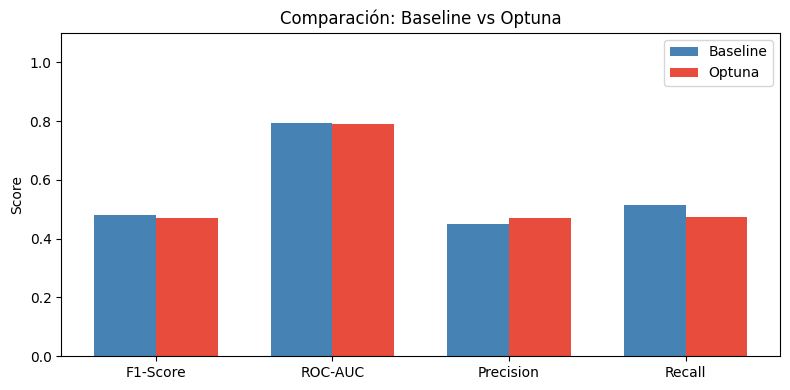

In [15]:
metrics = {
    "Modelo"    : ["Baseline", "Optuna"],
    "Threshold" : [round(threshold_baseline, 3), round(threshold_optuna, 3)],
    "F1-Score"  : [
        round(f1_score(y_test, y_pred_base_opt), 4),
        round(f1_score(y_test, y_pred_optuna), 4)
    ],
    "ROC-AUC"   : [
        round(roc_auc_score(y_test, y_proba_base), 4),
        round(roc_auc_score(y_test, y_proba_optuna), 4)
    ],
    "Precision" : [
        round(precision_score(y_test, y_pred_base_opt), 4),
        round(precision_score(y_test, y_pred_optuna), 4)
    ],
    "Recall"    : [
        round(recall_score(y_test, y_pred_base_opt), 4),
        round(recall_score(y_test, y_pred_optuna), 4)
    ],
}

df_compare = pd.DataFrame(metrics).set_index("Modelo")
print(df_compare.to_string())

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(4)
width = 0.35
cols  = ["F1-Score", "ROC-AUC", "Precision", "Recall"]

bars1 = ax.bar(x - width/2, df_compare.loc["Baseline", cols], width, label='Baseline', color='steelblue')
bars2 = ax.bar(x + width/2, df_compare.loc["Optuna",   cols], width, label='Optuna',   color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(cols)
ax.set_ylabel('Score')
ax.set_title('Comparación: Baseline vs Optuna')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

---
## 13. Guardar el Mejor Modelo

Seleccionamos el modelo con mayor **F1-Score** y lo guardamos como el modelo definitivo.

In [ ]:
f1_base   = f1_score(y_test, y_pred_base_opt)
f1_optuna = f1_score(y_test, y_pred_optuna)

if f1_optuna >= f1_base:
    best_model_obj   = xgb_optuna
    best_threshold   = threshold_optuna
    best_model_name  = "Optuna"
else:
    best_model_obj   = xgb_baseline
    best_threshold   = threshold_baseline
    best_model_name  = "Baseline"

best_artifact = {
    "model"    : best_model_obj,
    "threshold": best_threshold,
    "features" : X_train.columns.tolist(),
    "origin"   : best_model_name,
    "metrics"  : {
        "f1"       : round(max(f1_base, f1_optuna), 4),
        "roc_auc"  : round(roc_auc_score(y_test,
                           best_model_obj.predict_proba(X_test)[:, 1]), 4),
    }
}

joblib.dump(best_artifact, "../models/xgb_best_model.pkl")

print(f"   Mejor modelo: {best_model_name}")
print(f"   F1-Score  : {best_artifact['metrics']['f1']}")
print(f"   ROC-AUC   : {best_artifact['metrics']['roc_auc']}")
print(f"   Threshold : {best_threshold:.3f}")
print(f"\n💾 Guardado en: ../models/xgb_best_model.pkl")

✅ Mejor modelo: Baseline
   F1-Score  : 0.4793
   ROC-AUC   : 0.7917
   Threshold : 0.293

💾 Guardado en: ../models/xgb_best_model.pkl


In [3]:
import joblib
from sklearn.metrics import accuracy_score

artifact = joblib.load("../models/xgboost/xgb_best_model.pkl")
best_model = artifact["model"]

y_train_pred = best_model.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = best_model.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)

diff = abs(acc_train - acc_test) * 100
print(f"--- Final model overfitting rate ---")
print(f"Accuracy Train: {acc_train:.4f}")
print(f"Accuracy Test : {acc_test:.4f}")
print(f"Diferencia (Overfitting): {diff:.2f}%")

--- Final model overfitting rate ---
Accuracy Train: 0.9348
Accuracy Test : 0.8914
Diferencia (Overfitting): 4.34%
